In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
from sklearn.metrics import classification_report
import joblib
import shap
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.float_format', '{:,.3f}'.format)

In [62]:
customer_data = pd.read_csv("Datasets/customers.csv")
print(customer_data.shape)

customer_data.head()

(50000, 12)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001


In [63]:
loans_data = pd.read_csv("Datasets/loans.csv")
print(loans_data.shape)

loans_data.head()

(50000, 15)


,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,"49,340.000",444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,"77,660.000",698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,"43,400.000",390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,"34,940.000",314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,"90,400.000",813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [64]:
bureau_data = pd.read_csv("Datasets/bureau_data.csv")
print(bureau_data.shape)

bureau_data.head()

(50000, 8)


,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10


In [65]:
complete_data = pd.merge(customer_data, loans_data, how="inner", on="cust_id")

print(complete_data.shape)
complete_data.head()

(50000, 26)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,"49,340.000",444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,"77,660.000",698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,"43,400.000",390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,"34,940.000",314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,"90,400.000",813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [66]:
final_complete_data = pd.merge(complete_data, bureau_data, on="cust_id")

print(final_complete_data.shape)
final_complete_data.head()

(50000, 33)


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [67]:
# Checking Missing Values
final_complete_data.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 62
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
default                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_mon

In [68]:
df = final_complete_data.fillna(final_complete_data["residence_type"].mode()[0])
# Checking Missing Values after Handling Null Values in Residence Type Column
df.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd 

In [69]:
# Checking Duplicate Values
df.duplicated().sum()

np.int64(0)

In [70]:
# Dropping ID Columns
df.drop(columns=["cust_id", "loan_id"], inplace=True)

In [71]:
df['zipcode'] = df['zipcode'].astype(str)

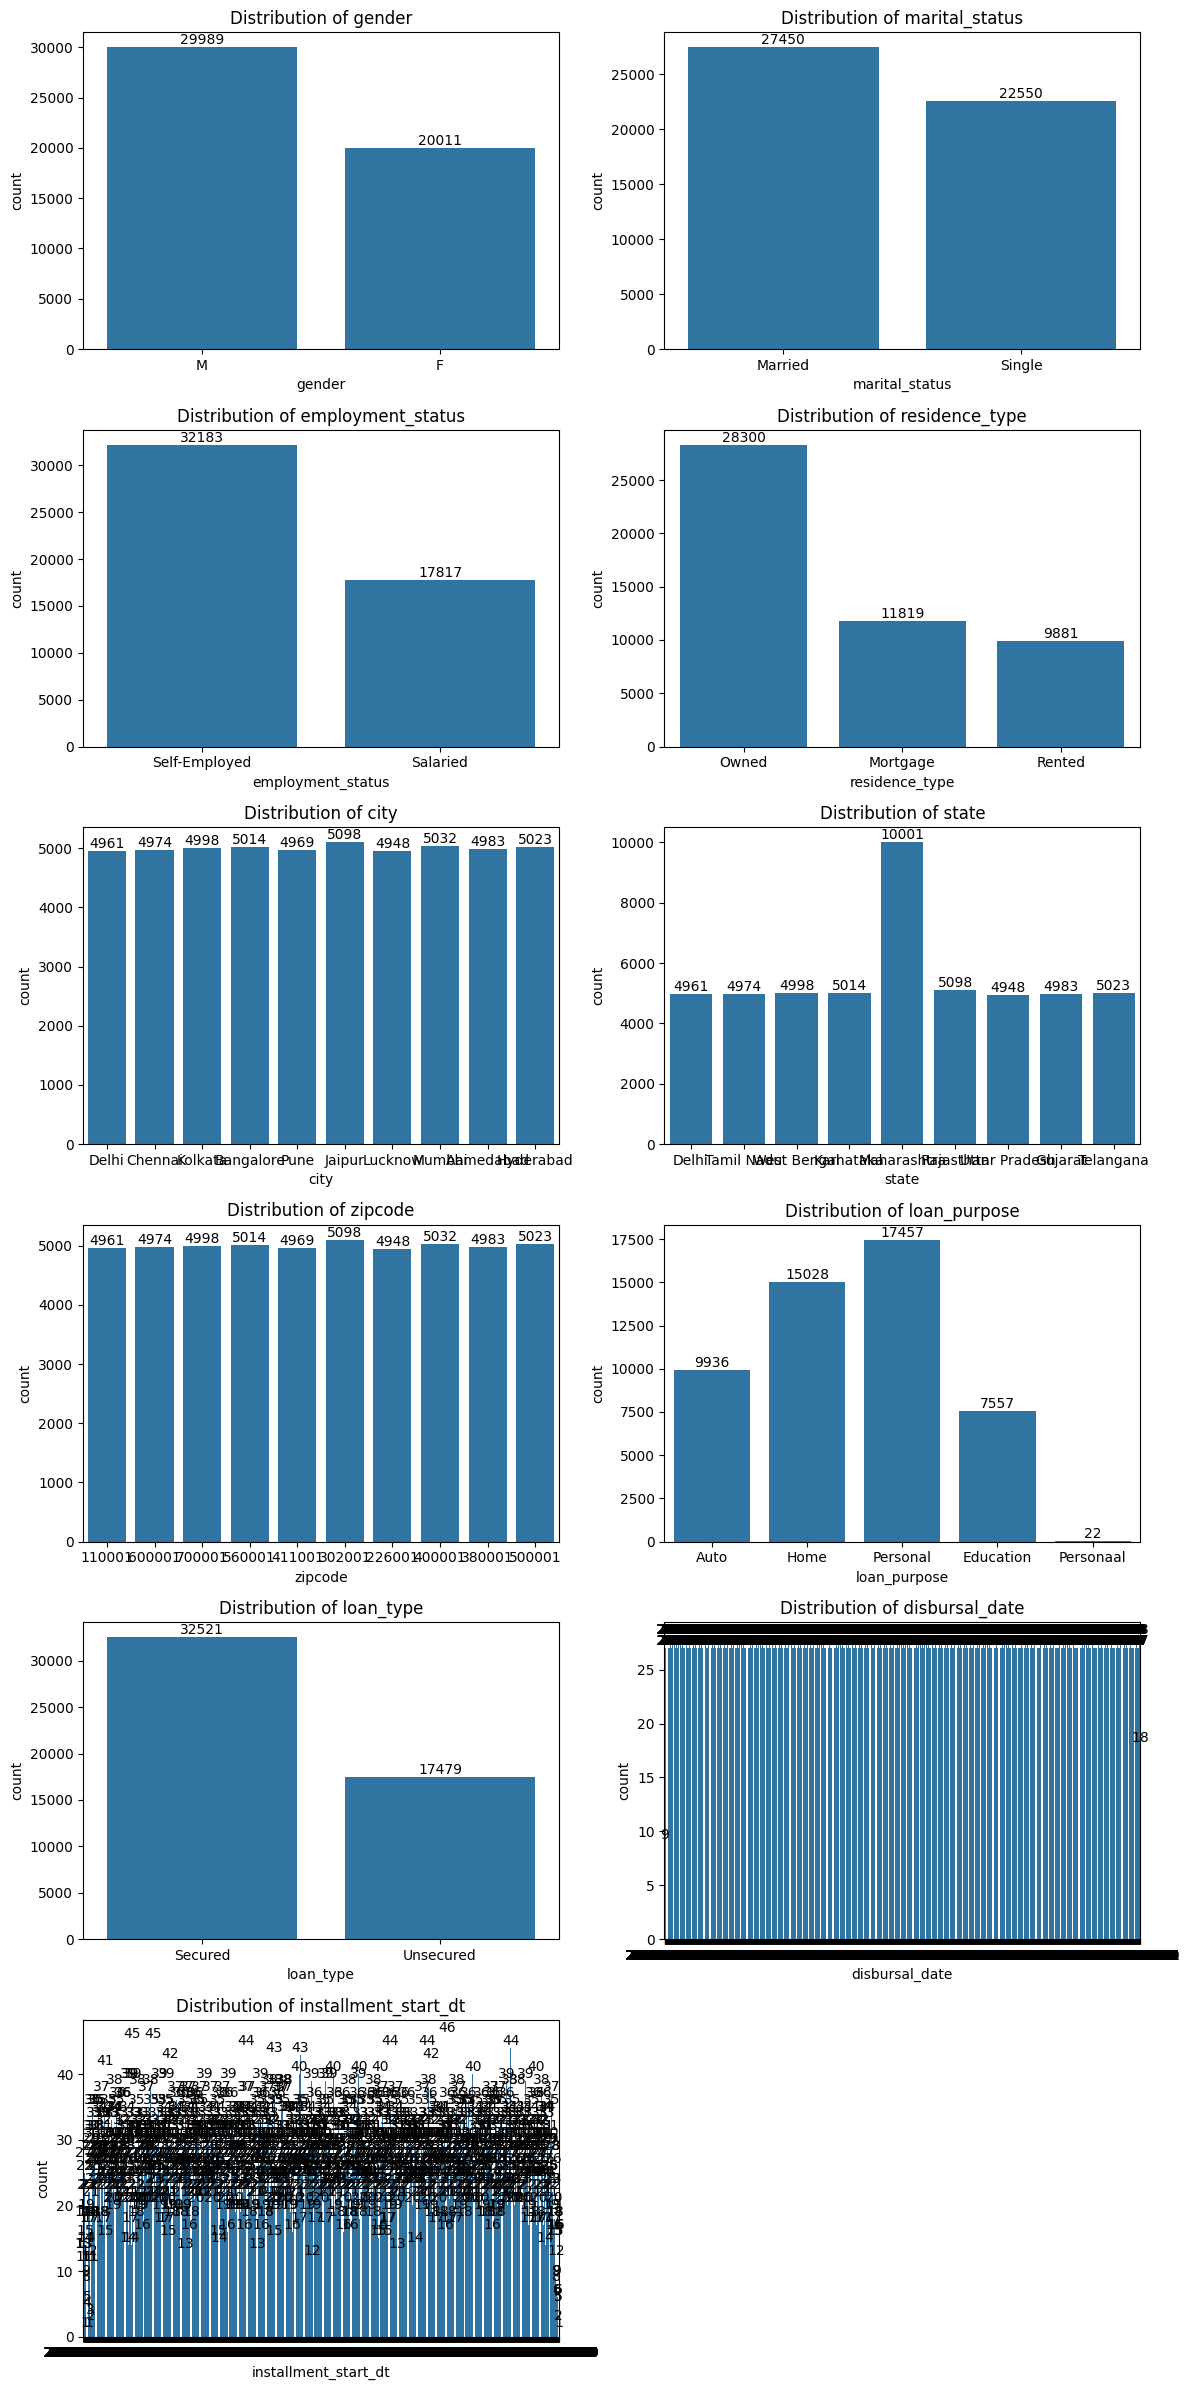

In [72]:
col_names = df.select_dtypes("object").columns

ncols = 2
nrows = math.ceil(len(col_names)/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))

for ax, col in zip(axes.flat, col_names):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.bar_label(ax.containers[0])

for ax in axes.flat[len(col_names):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

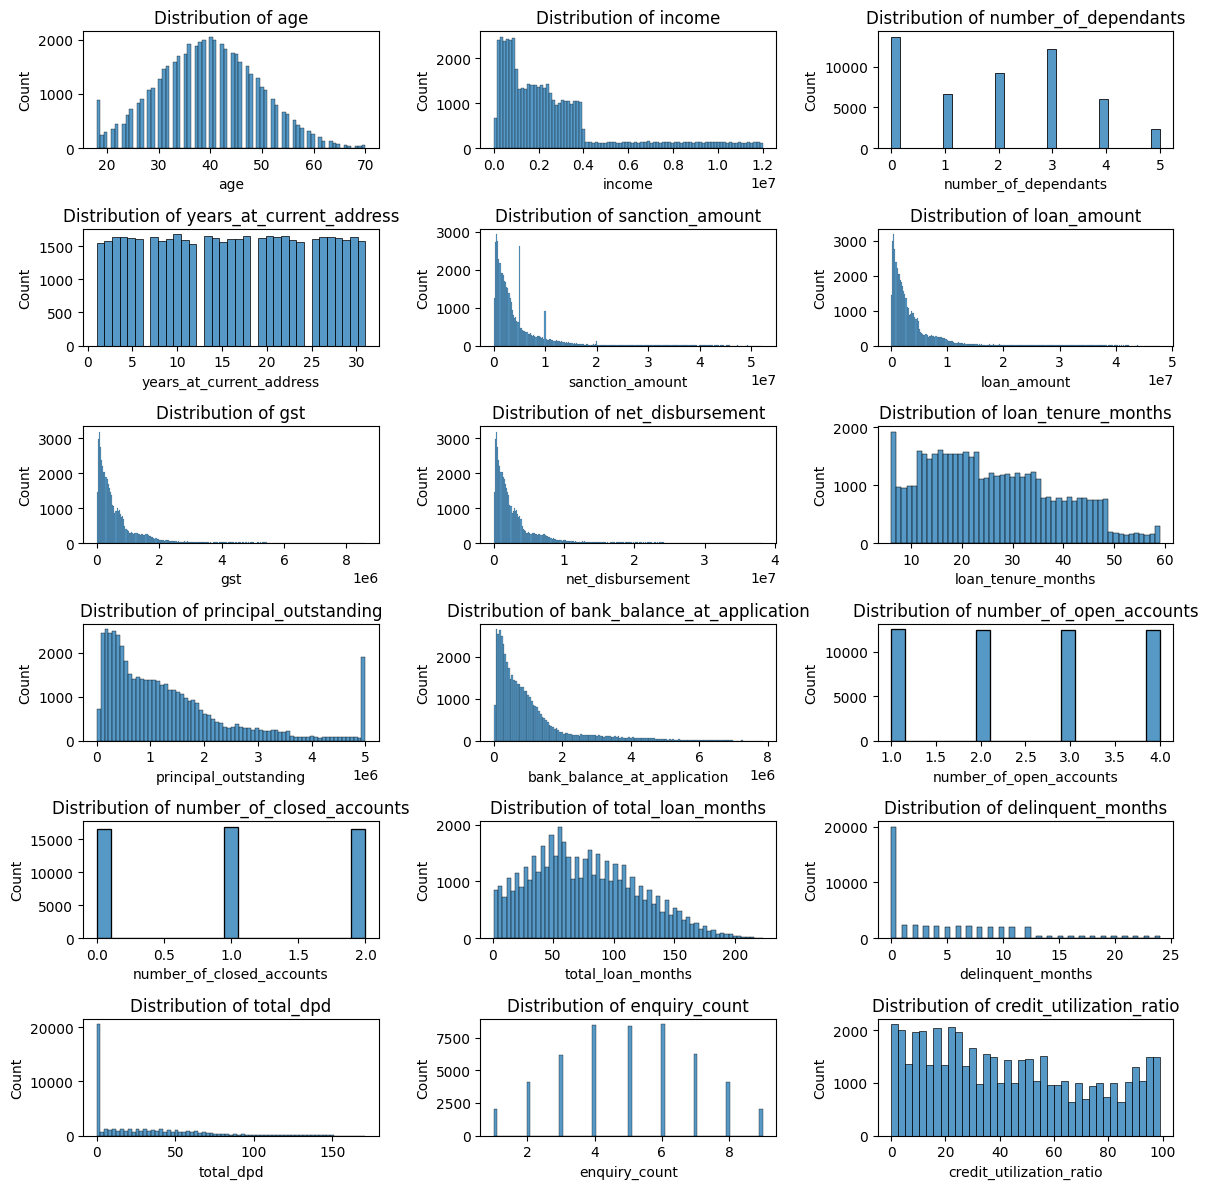

In [73]:
num_names = df.select_dtypes("int").columns

ncols = 3
nrows = math.ceil(len(num_names)/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12,4*ncols))

for ax, col in zip(axes.flat, num_names):
    sns.histplot(data=df, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")

for ax in axes.flat[len(num_names):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [74]:
# Checking Statistical Information of the Dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,"50,000.000",39.551,9.848,18.000,33.000,40.000,46.000,70.000
income,"50,000.000","2,640,897.500","2,629,441.055",0.000,"803,000.000","1,892,000.000","3,332,250.000","11,999,000.000"
number_of_dependants,"50,000.000",1.940,1.536,0.000,0.000,2.000,3.000,5.000
years_at_current_address,"50,000.000",16.018,8.926,1.000,8.000,16.000,24.000,31.000
sanction_amount,"50,000.000","4,704,827.520","6,267,276.393",0.000,"1,147,000.000","2,656,000.000","5,172,250.000","52,175,000.000"
loan_amount,"50,000.000","3,999,678.800","5,376,552.033",0.000,"967,000.000","2,240,000.000","4,611,000.000","47,819,000.000"
processing_fee,"50,000.000","80,494.708","117,312.262",0.000,"19,340.000","44,800.000","92,240.000","5,698,029.901"
gst,"50,000.000","719,942.184","967,779.366",0.000,"174,060.000","403,200.000","829,980.000","8,607,420.000"
net_disbursement,"50,000.000","3,199,743.040","4,301,241.627",0.000,"773,600.000","1,792,000.000","3,688,800.000","38,255,200.000"
loan_tenure_months,"50,000.000",25.941,12.433,6.000,16.000,24.000,35.000,59.000


In [75]:
df_1 = df[(df["processing_fee"])<(df["loan_amount"]*0.4)]
df_1.shape

(49985, 31)

In [76]:
df_1[(df_1["principal_outstanding"])<0]

,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio


In [77]:
(df_1['loan_amount'] > df_1['sanction_amount']).sum()

np.int64(0)

In [78]:
(df_1['net_disbursement'] > df_1['loan_amount']).sum()

np.int64(0)

In [79]:
df_1.head()

,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [80]:
df_1["default"] = df_1["default"].astype("int")

default      0     1
gender              
F        18247  1758
M        27441  2539


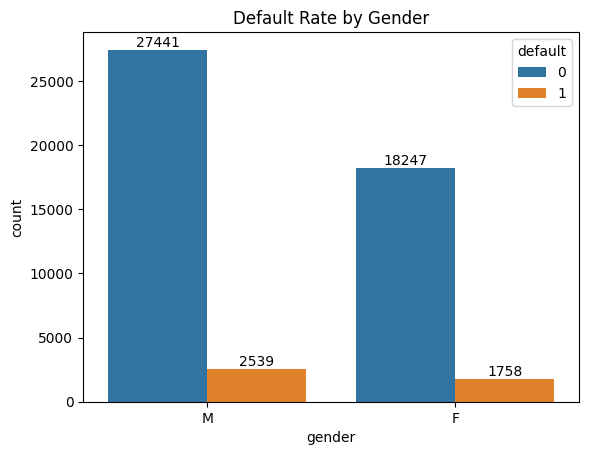

In [81]:
print(pd.crosstab(df["gender"], df_1["default"]))

ax = sns.countplot(data=df_1, x="gender", hue="default")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Default Rate by Gender")
plt.show()

default                0     1
employment_status             
Salaried           16178  1634
Self-Employed      29510  2663


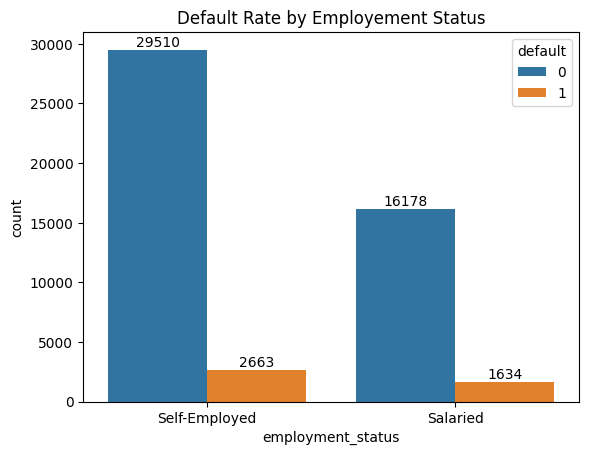

In [82]:
print(pd.crosstab(df["employment_status"], df_1["default"]))

ax = sns.countplot(data=df_1, x="employment_status", hue="default")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Default Rate by Employement Status")
plt.show()

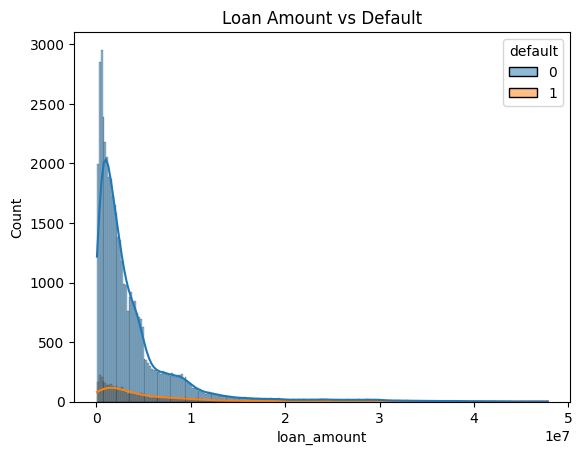

In [83]:
sns.histplot(data=df_1, x="loan_amount", hue="default", kde=True)
plt.title("Loan Amount vs Default")
plt.show()

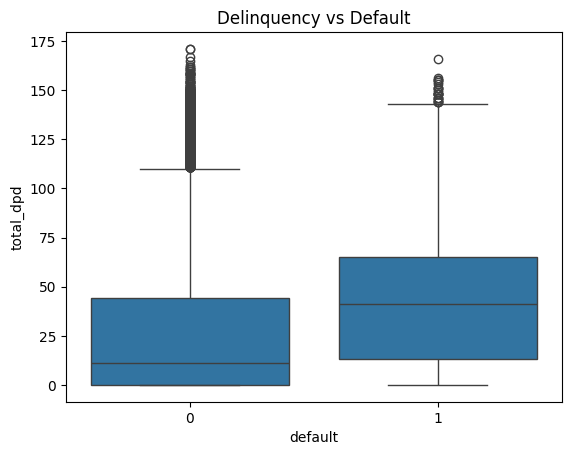

In [84]:
sns.boxplot(data=df_1, y="total_dpd", x="default")
plt.title("Delinquency vs Default")
plt.show()

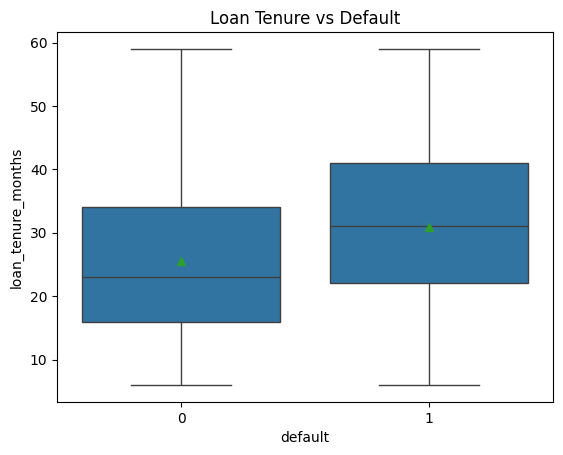

In [85]:
sns.boxplot(
    data=df_1,
    x='default',
    y='loan_tenure_months',
    showmeans=True
)
plt.title("Loan Tenure vs Default")
plt.show()

In [86]:
df_1.head()

,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,...,2019-07-24,2019-08-10,0,1,1,42,0,0,3,7
1,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,...,2019-07-24,2019-08-15,0,3,1,96,12,60,5,4
2,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,...,2019-07-24,2019-08-21,0,2,1,82,24,147,6,58
3,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,...,2019-07-24,2019-08-09,0,3,0,115,15,87,5,26
4,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,...,2019-07-24,2019-08-02,0,4,2,120,0,0,5,10


In [87]:
df_1.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'default', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio'],
      dtype='object')

In [88]:
df_2 = df_1.drop(columns=["zipcode", "disbursal_date", "installment_start_dt", "default"], axis=1)
df_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'loan_purpose', 'loan_type', 'sanction_amount',
       'loan_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio'],
      dtype='object')

In [89]:
# Performing VIF operation to select best numerical variables
col_to_scale = df_2.select_dtypes("int").columns

scale = MinMaxScaler()

df_2[col_to_scale] = scale.fit_transform(df_2[col_to_scale])

def apply_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Columns"] = data.columns
    vif_df["VIF Value"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

vif_df = apply_vif(df_2[col_to_scale])
vif_df

,Columns,VIF Value
0,age,5.594
1,income,34.765
2,number_of_dependants,2.712
3,years_at_current_address,3.332
4,sanction_amount,100.936
5,loan_amount,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,3.955
9,principal_outstanding,26.178


In [90]:
df_2[['sanction_amount',
      'loan_amount',
      'net_disbursement']].corr()

,sanction_amount,loan_amount,net_disbursement
sanction_amount,1.000,0.992,0.992
loan_amount,0.992,1.000,1.000
net_disbursement,0.992,1.000,1.000


In [91]:
df_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'loan_purpose', 'loan_type', 'sanction_amount',
       'loan_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio'],
      dtype='object')

In [92]:
df_3 = df_2.drop(["net_disbursement", "delinquent_months", "gender", "marital_status","employment_status", 
"city", "state", "loan_purpose", "loan_type", "residence_type", "sanction_amount", "processing_fee", "gst", 
"principal_outstanding", "bank_balance_at_application"], axis = 1)



def apply_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Columns"] = data.columns
    vif_df["VIF Value"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

vif_df = apply_vif(df_3)
vif_df

,Columns,VIF Value
0,age,5.330
1,income,4.081
2,number_of_dependants,2.711
3,years_at_current_address,3.327
4,loan_amount,3.730
5,loan_tenure_months,3.918
6,number_of_open_accounts,8.126
7,number_of_closed_accounts,2.345
8,total_loan_months,9.529
9,total_dpd,1.636


In [93]:
cat_columns = df_1.select_dtypes("object").columns

def calculate_iv(df, features, target):

    temp = pd.crosstab(df[features], df[target])

    temp.columns = ["good", "bad"]

    temp["good_pct"] = temp["good"]/temp["good"].sum()
    temp["bad_pct"] = temp["bad"] / temp["bad"].sum()

    temp["good_pct"] = temp["good_pct"].replace(0, 0.0001)
    temp["bad_pct"] = temp["bad_pct"].replace(0, 0.0001)

    temp["WOE"] = np.log(temp["good_pct"] / temp["bad_pct"])

    temp["IV"] = (temp["good_pct"] - temp["bad_pct"]) * temp["WOE"]

    return temp["IV"].sum()


iv_results = pd.DataFrame()
iv_results["Features"] = cat_columns

iv_results["IV_Value"] = [calculate_iv(df_1, col, "default") for col in cat_columns]

print(iv_results.sort_values("IV_Value", ascending=False))


                Features  IV_Value
10  installment_start_dt     0.473
9         disbursal_date     0.441
7           loan_purpose     0.385
3         residence_type     0.247
8              loan_type     0.168
2      employment_status     0.003
1         marital_status     0.002
6                zipcode     0.001
4                   city     0.001
5                  state     0.001
0                 gender     0.000


In [94]:
selected_features = ["loan_purpose", "residence_type", "loan_type", "age", "income", "number_of_dependants",
                     "years_at_current_address", "loan_amount", "loan_tenure_months", "number_of_open_accounts", 
                     "number_of_closed_accounts", "total_loan_months", "total_dpd", "enquiry_count", "credit_utilization_ratio", "default"]

selected_df = df_1[selected_features]
selected_df.head()

,loan_purpose,residence_type,loan_type,age,income,number_of_dependants,years_at_current_address,loan_amount,loan_tenure_months,number_of_open_accounts,number_of_closed_accounts,total_loan_months,total_dpd,enquiry_count,credit_utilization_ratio,default
0,Auto,Owned,Secured,44,2586000,3,27,2467000,33,1,1,42,0,3,7,0
1,Home,Owned,Secured,38,1206000,3,4,3883000,30,3,1,96,60,5,4,0
2,Personal,Owned,Unsecured,46,2878000,3,24,2170000,21,2,1,82,147,6,58,0
3,Personal,Owned,Unsecured,55,3547000,1,15,1747000,6,3,0,115,87,5,26,0
4,Auto,Owned,Secured,37,3432000,3,28,4520000,28,4,2,120,0,5,10,0


In [95]:
df_2["loan_purpose"].value_counts()

loan_purpose
Personal     17451
Home         15025
Auto          9933
Education     7554
Personaal       22
Name: count, dtype: int64

In [96]:
selected_df["loan_purpose"] = selected_df["loan_purpose"].map({
    "Personal": "Personal",
    "Personaal": "Personal",
    "Home": "Home",
    "Auto": "Auto",
    "Education": "Education"
})

In [97]:
selected_df = pd.get_dummies(selected_df, columns=["loan_purpose", "residence_type", "loan_type"], drop_first=True)
selected_df.head()

,age,income,number_of_dependants,years_at_current_address,loan_amount,loan_tenure_months,number_of_open_accounts,number_of_closed_accounts,total_loan_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
0,44,2586000,3,27,2467000,33,1,1,42,0,3,7,0,False,False,False,True,False,False
1,38,1206000,3,4,3883000,30,3,1,96,60,5,4,0,False,True,False,True,False,False
2,46,2878000,3,24,2170000,21,2,1,82,147,6,58,0,False,False,True,True,False,True
3,55,3547000,1,15,1747000,6,3,0,115,87,5,26,0,False,False,True,True,False,True
4,37,3432000,3,28,4520000,28,4,2,120,0,5,10,0,False,False,False,True,False,False


In [ ]:
X = selected_df.drop("default", axis = 1)
y = selected_df["default"]

num_cols = X.select_dtypes("int").columns

scale = MinMaxScaler()

X[num_cols] = scale.fit_transform(X[num_cols])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [118]:
X

,age,income,number_of_dependants,years_at_current_address,loan_amount,loan_tenure_months,number_of_open_accounts,number_of_closed_accounts,total_loan_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
0,0.500,0.209,0.600,0.867,0.051,0.509,0.000,0.500,0.185,0.000,0.250,0.071,False,False,False,True,False,False
1,0.385,0.093,0.600,0.100,0.080,0.453,0.667,0.500,0.428,0.351,0.500,0.040,False,True,False,True,False,False
2,0.538,0.233,0.600,0.767,0.044,0.283,0.333,0.500,0.365,0.860,0.625,0.586,False,False,True,True,False,True
3,0.712,0.290,0.200,0.467,0.036,0.000,0.667,0.000,0.514,0.509,0.500,0.263,False,False,True,True,False,True
4,0.365,0.280,0.600,0.900,0.094,0.415,1.000,1.000,0.536,0.000,0.500,0.101,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.423,0.057,0.400,0.333,0.010,0.302,1.000,1.000,0.739,0.035,0.875,0.242,False,False,True,True,False,True
49996,0.404,0.254,0.000,0.267,0.067,0.170,1.000,0.000,0.721,0.000,0.375,0.919,False,False,False,True,False,False
49997,0.519,0.103,0.000,0.867,0.077,0.585,1.000,0.500,0.185,0.000,0.750,0.384,False,True,False,False,True,False
49998,0.462,0.036,0.400,0.633,0.033,0.585,0.000,1.000,0.185,0.275,0.375,0.172,False,True,False,False,False,False


#### Model Training with default parameters

In [99]:
lr = LogisticRegression(class_weight="balanced")

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.99      0.86      0.92      9171
           1       0.37      0.90      0.52       826

    accuracy                           0.87      9997
   macro avg       0.68      0.88      0.72      9997
weighted avg       0.94      0.87      0.89      9997



In [100]:
xgb = XGBClassifier(scale_pos_weight=9)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      9171
           1       0.68      0.86      0.76       826

    accuracy                           0.95      9997
   macro avg       0.83      0.91      0.87      9997
weighted avg       0.96      0.95      0.96      9997



In [101]:
lightgbm = LGBMClassifier(class_weight="balanced")

lightgbm.fit(X_train, y_train)

y_pred_lightgbm = lightgbm.predict(X_test)

print(classification_report(y_test, y_pred_lightgbm))

[LightGBM] [Info] Number of positive: 3471, number of negative: 36517
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001380 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 39988, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      9171
           1       0.57      0.94      0.71       826

    accuracy                           0.94      9997
   macro avg       0.78      0.94      0.84      9997
weighted avg       0.96      0.94      0.94      9997



#### Model Training with Tuned Parameters using Optuna

In [102]:
def objective_for_logistic_regression(trial):

    C = trial.suggest_float("C", 0.001, 100)
    solver = trial.suggest_categorical("solver", ['liblinear', 'lbfgs', 'saga'])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    lr = LogisticRegression(
        C=C,
        solver=solver,
        class_weight=class_weight
    )

    score = cross_val_score(lr, X_train, y_train, cv=3, scoring="f1").mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective_for_logistic_regression, n_trials=50)

print("Best trial score:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2026-06-16 00:13:34,469] A new study created in memory with name: no-name-7f3c1dbe-7f2b-4c37-8469-ea01828098fd
[I 2026-06-16 00:13:34,983] Trial 0 finished with value: 0.5455533307213668 and parameters: {'C': 96.98709189252604, 'solver': 'liblinear', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5455533307213668.
[I 2026-06-16 00:13:35,343] Trial 1 finished with value: 0.5450034506823785 and parameters: {'C': 3.38861715255726, 'solver': 'lbfgs', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.5455533307213668.
[I 2026-06-16 00:13:35,742] Trial 2 finished with value: 0.6469906359718935 and parameters: {'C': 11.123275212765371, 'solver': 'liblinear', 'class_weight': None}. Best is trial 2 with value: 0.6469906359718935.
[I 2026-06-16 00:13:36,162] Trial 3 finished with value: 0.6479020496094743 and parameters: {'C': 78.39808387934744, 'solver': 'saga', 'class_weight': None}. Best is trial 3 with value: 0.6479020496094743.
[I 2026-06-16 00:13:36,455] Trial 4 fin

Best trial score: 0.6500104728095634
Best hyperparameters: {'C': 35.78406716638583, 'solver': 'lbfgs', 'class_weight': None}


In [103]:
def objective_for_xgboost(trials):

    learning_rate = trials.suggest_float("learning_rate", 0, 1.0)
    n_estimators = trials.suggest_int("n_estimators", 10, 300)
    max_depth = trials.suggest_int("max_depth", 3, 10)
    scale_pos_weight= trials.suggest_int("scale_pos_weight", 1,15)

    xgb = XGBClassifier(learning_rate=learning_rate,
                        n_estimators=n_estimators,
                        max_depth=max_depth,
                        scale_pos_weight=scale_pos_weight)

    score = cross_val_score(xgb, X_train, y_train, cv=3, scoring="f1").mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_for_xgboost, n_trials=50)

print("Best Trial Score: ", study.best_value)
print("Best Hyperparamters: ", study.best_params)

[I 2026-06-16 00:13:51,700] A new study created in memory with name: no-name-22676c8c-6364-4d61-afb5-4821eadf3d00
[I 2026-06-16 00:13:52,390] Trial 0 finished with value: 0.7557966292390125 and parameters: {'learning_rate': 0.2579102823274233, 'n_estimators': 122, 'max_depth': 4, 'scale_pos_weight': 6}. Best is trial 0 with value: 0.7557966292390125.
[I 2026-06-16 00:13:53,398] Trial 1 finished with value: 0.740924402742437 and parameters: {'learning_rate': 0.7180133026570718, 'n_estimators': 113, 'max_depth': 9, 'scale_pos_weight': 3}. Best is trial 0 with value: 0.7557966292390125.
[I 2026-06-16 00:13:53,872] Trial 2 finished with value: 0.727509584440248 and parameters: {'learning_rate': 0.04622382952343185, 'n_estimators': 113, 'max_depth': 3, 'scale_pos_weight': 2}. Best is trial 0 with value: 0.7557966292390125.
[I 2026-06-16 00:13:54,681] Trial 3 finished with value: 0.7500202064281957 and parameters: {'learning_rate': 0.8085485573317074, 'n_estimators': 68, 'max_depth': 10, 'sc

Best Trial Score:  0.76108343567939
Best Hyperparamters:  {'learning_rate': 0.3085520411977658, 'n_estimators': 283, 'max_depth': 10, 'scale_pos_weight': 8}


In [104]:
xgb = XGBClassifier(learning_rate= 0.2924882213325183, n_estimators= 244, 
                    max_depth = 3, scale_pos_weight= 3)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      9171
           1       0.71      0.85      0.77       826

    accuracy                           0.96      9997
   macro avg       0.85      0.91      0.88      9997
weighted avg       0.96      0.96      0.96      9997



In [105]:
def objective_for_lightgbm(trials):

    params = {
        "n_estimators": trials.suggest_int("n_estimators", 10, 300),
        "learning_rate": trials.suggest_float("learning_rate", 0, 10),
        "num_leaves": trials.suggest_int("num_leaves", 3, 20),
        "max_depth": trials.suggest_int("max_depth", 3, 12)
    }

    lgm = LGBMClassifier(**params)

    score = cross_val_score(lgm, X_train, y_train, cv=3, scoring="f1").mean()

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective_for_lightgbm, n_trials=50)

print("Best Hyperparameters", study.best_params)
print("Best Score", study.best_value)

[I 2026-06-16 00:16:04,630] A new study created in memory with name: no-name-5716b89c-b6ca-4130-ab5d-2bd442ef2942


[LightGBM] [Info] Number of positive: 2314, number of negative: 24344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1154
[LightGBM] [Info] Number of data points in the train set: 26658, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.086803 -> initscore=-2.353308
[LightGBM] [Info] Start training from score -2.353308
[LightGBM] [Info] Number of positive: 2314, number of negative: 24345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1155
[LightGBM] [Info] Number of data points in the train set: 26659, number of used features: 18
[LightGBM] [Info] [b

[I 2026-06-16 00:16:05,441] Trial 0 finished with value: 0.754060601064602 and parameters: {'n_estimators': 139, 'learning_rate': 0.4196755433488564, 'num_leaves': 3, 'max_depth': 12}. Best is trial 0 with value: 0.754060601064602.


[LightGBM] [Info] Number of positive: 2314, number of negative: 24344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1154
[LightGBM] [Info] Number of data points in the train set: 26658, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.086803 -> initscore=-2.353308
[LightGBM] [Info] Start training from score -2.353308
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training b

[I 2026-06-16 00:16:06,432] Trial 1 finished with value: 0.3467623696990696 and parameters: {'n_estimators': 143, 'learning_rate': 1.341443547186122, 'num_leaves': 16, 'max_depth': 12}. Best is trial 0 with value: 0.754060601064602.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[I 2026-06-16 00:17:15,543] Trial 48 finished with value: 0.12366680646406762 and parameters: {'n_estimators': 100, 'learning_rate': 2.074422628735488, 'num_leaves': 6, 'max_depth': 10}. Best is trial 43 with value: 0.7555003074977512.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1156
[LightGBM] [Info] Number of data points in the train set: 26659, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.086800 -> initscore=-2.353349
[LightGBM] [Info] Start training from score -2.353349
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet

[I 2026-06-16 00:17:17,864] Trial 49 finished with value: 0.743194607808552 and parameters: {'n_estimators': 260, 'learning_rate': 0.5209727876103103, 'num_leaves': 16, 'max_depth': 6}. Best is trial 43 with value: 0.7555003074977512.


Best Hyperparameters {'n_estimators': 285, 'learning_rate': 0.08975860376057442, 'num_leaves': 18, 'max_depth': 9}
Best Score 0.7555003074977512


In [106]:
lightgbm = LGBMClassifier(class_weight="balanced", n_estimators= 153, learning_rate= 0.06898246494092566, 
                          num_leaves= 20, max_depth= 11)

lightgbm.fit(X_train, y_train)

y_pred_lightgbm = lightgbm.predict(X_test)

print(classification_report(y_test, y_pred_lightgbm))

[LightGBM] [Info] Number of positive: 3471, number of negative: 36517
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1162
[LightGBM] [Info] Number of data points in the train set: 39988, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      9171
           1       0.55      0.95      0.70       826

    accuracy                           0.93      9997
   macro avg       0.77      0.94      0.83      9997
weighted avg       0.96      0.93      0.94      9997



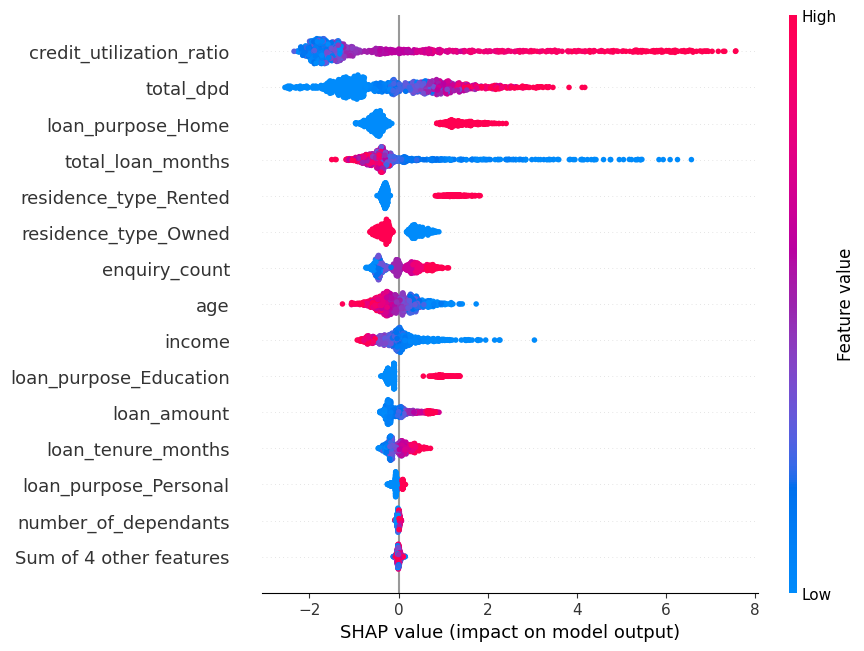

In [107]:
sample_size = 1000

x_shap_sample, _, y_shap_sample, _ = train_test_split(X_test, y_test, train_size=sample_size, stratify=y_test, random_state=42)

explainer = shap.TreeExplainer(lightgbm)
shap_values = explainer(x_shap_sample)

shap.plots.beeswarm(shap_values, max_display=15)

In [108]:
joblib.dump(lightgbm, "Risk_Modelling_Results/lightgbm.joblib")
joblib.dump(scale, "Risk_Modelling_Results/scale.joblib")

['Risk_Modelling_Results/scale.joblib']

In [109]:
age_idx = list(num_names).index("age")

age_min = scale.data_min_[age_idx]
age_max = scale.data_max_[age_idx]

original_age = (X_test["age"]*(age_max - age_min)) + age_min 

In [110]:
y_pred_lgm = lightgbm.predict(X_test)
y_prob_lgm = lightgbm.predict_proba(X_test)[:,1]


analysis_df = pd.DataFrame({
    "True Labels": y_test,
    "Predicted Labels": y_pred_lgm,
    "Predicted Probablity": y_prob_lgm,
    "age": original_age
})

analysis_df.head()

,True Labels,Predicted Labels,Predicted Probablity,age
18112,0,0,0.000,43.000
48179,0,0,0.000,58.000
30595,0,0,0.011,38.000
19821,0,0,0.176,37.000
20260,0,1,0.732,41.000


In [111]:
analysis_df["age_group"] = pd.cut(analysis_df["age"],
                                  bins=[0, 25, 40, 60, 100],
                                  labels=["Under 25", "25-40", "41-60", "Above 60"])

analysis_df.head()

,True Labels,Predicted Labels,Predicted Probablity,age,age_group
18112,0,0,0.000,43.000,41-60
48179,0,0,0.000,58.000,41-60
30595,0,0,0.011,38.000,25-40
19821,0,0,0.176,37.000,25-40
20260,0,1,0.732,41.000,41-60


In [112]:
metric_frame_age = MetricFrame(
    metrics = {
        "selection_rate": selection_rate,
        "tpr": true_positive_rate,
        "fpr": false_positive_rate
    },
    y_true = analysis_df["True Labels"],
    y_pred = analysis_df["Predicted Labels"],
    sensitive_features = analysis_df["age_group"]
)

print("Age Demographic Parity Ratio: ", metric_frame_age.ratio()["selection_rate"])
print("Age Equalized Odds (TPR) Ratio: ", metric_frame_age.ratio()["tpr"])

Age Demographic Parity Ratio:  0.5097545626179988
Age Equalized Odds (TPR) Ratio:  0.9


In [113]:
metric_frame_age.by_group

,selection_rate,tpr,fpr
age_group,,,
25-40,0.161,0.962,0.079
41-60,0.125,0.950,0.063
Above 60,0.084,1.000,0.041
Under 25,0.164,0.900,0.072


The fairness analysis across age groups indicates moderate demographic disparity. The model predicts default for 16.4% of applicants under 25 and only 8.4% of applicants above 60, suggesting lower selection rates for older customers. However, Equal Opportunity is largely maintained, with True Positive Rates ranging from 0.90 to 1.00 across age groups, indicating that actual defaulters are identified consistently regardless of age. False Positive Rates are also relatively low, ranging from 0.041 to 0.079. Overall, while demographic parity is not fully achieved, the model demonstrates reasonably balanced performance under Equal Opportunity and Equalized Odds criteria.

In [114]:
selected_features

['loan_purpose',
 'residence_type',
 'loan_type',
 'age',
 'income',
 'number_of_dependants',
 'years_at_current_address',
 'loan_amount',
 'loan_tenure_months',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'total_loan_months',
 'total_dpd',
 'enquiry_count',
 'credit_utilization_ratio',
 'default']

In [ ]:
loan_purpose = input(
    "Please Select Loan Purpose (Business/Home/Personal/Education): "
).strip().title()

residence_type = input(
    "Please Select Residence Type (Mortgage/Owned/Rented): "
).strip().title()

loan_type = input(
    "Please Select Loan Type (Secured/Unsecured): "
).strip().title()

customer_age = int(input("Please Enter your Age: "))
customer_income = float(input("Please Enter your Annual Income: "))
customer_dependants = int(input("Please Enter your Number of Dependants: "))
customer_year_current_address = int(
    input("Please Enter Years at Current Address: ")
)

loan_amount = float(input("Please Enter Loan Amount: "))
loan_tenure_months = int(input("Please Enter Loan Tenure (Months): "))
number_of_open_accounts = int(input("Please Enter Number of Open Accounts: "))
number_of_closed_accounts = int(input("Please Enter Number of Closed Accounts: "))
total_loan_months = int(input("Please Enter Total Loan Months: "))
total_dpd = int(input("Please Enter Total DPD: "))
enquiry_count = int(input("Please Enter Enquiry Count: "))
credit_utilization_ratio = float(
    input("Please Enter Credit Utilization Ratio: ")
)


# One-Hot Encoding
loan_purpose_home = 1 if loan_purpose == "Home" else 0
loan_purpose_education = 1 if loan_purpose == "Education" else 0
loan_purpose_personal = 1 if loan_purpose == "Personal" else 0

loan_residence_type_mortgage = 1 if residence_type == "Mortgage" else 0
loan_residence_type_owned = 1 if residence_type == "Owned" else 0
loan_residence_type_rented = 1 if residence_type == "Rented" else 0

loan_type_secured = 1 if loan_type == "Secured" else 0
loan_type_unsecured = 1 if loan_type == "Unsecured" else 0

In [128]:
# Create a Dataframe for Prediction

customer_input_df = pd.DataFrame({
    "age": [customer_age],
    "income": [customer_income],
    "number_of_dependants": [customer_dependants],
    "years_at_current_address": [customer_year_current_address],
    "loan_amount": [loan_amount],
    "loan_tenure_months": [loan_tenure_months],
    "number_of_open_accounts": [number_of_open_accounts],
    "number_of_closed_accounts": [number_of_closed_accounts],
    "total_loan_months": [total_loan_months],
    "total_dpd": [total_dpd],
    "enquiry_count": [enquiry_count],
    "credit_utilization_ratio": [credit_utilization_ratio],

    "loan_purpose_Education": [loan_purpose_education],
    "loan_purpose_Home": [loan_purpose_home],
    "loan_purpose_Personal": [loan_purpose_personal],

    "residence_type_Owned": [loan_residence_type_owned],
    "residence_type_Rented": [loan_residence_type_rented],

    "loan_type_Unsecured": [loan_type_unsecured]
})

customer_input_df.head()


,age,income,number_of_dependants,years_at_current_address,loan_amount,loan_tenure_months,number_of_open_accounts,number_of_closed_accounts,total_loan_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
0,24,"500,000.000",3,0,"400,000.000",120,2,3,120,10,2,0.400,0,1,0,1,0,1


In [134]:
customer_input_df[num_cols] = scale.transform(customer_input_df[num_cols])

customer_input_prediction = lightgbm.predict(customer_input_df)
customer_input_prediction_prob = lightgbm.predict_proba(customer_input_df)[:, 1]

print(f"Prediction: {customer_input_prediction}")
print(f"Prediction Probability: {customer_input_prediction_prob}")

Prediction: [1]
Prediction Probability: [0.74787767]
